# Análisis de Velocidades Atómicas — Simulación de Dinámica Molecular

**Sistema:** Tripéptido **ACE-ALA-ARG-VAL-NME** (ARV) en solución acuosa  
**Campo de fuerzas:** CHARMM27 · **Modelo de agua:** TIP3P  
**Herramienta:** GROMACS · `gmx traj -ov -len`  
**Temperaturas simuladas:** 298 K y 400 K

Se analiza la evolución temporal y distribución de las velocidades de 5 átomos
seleccionados de la proteína a 298 K y 400 K.

| Átomo | Residuo | Tipo | Masa (u) | Justificación |
|:-----:|---------|------|:--------:|---------------|
| 15 | ALA-2 | C (carbonilo backbone) | 12.011 | Vértice del enlace C=O y ángulo CA–C=O estudiados |
| 16 | ALA-2 | O (carbonilo backbone) | 15.999 | Extremo del enlace C=O; átomo más pesado de la selección |
| 17 | ARG-3 | N (amida backbone)     | 14.007 | Nitrógeno amídico del backbone; masa intermedia |
| 32 | ARG-3 | CZ (guanidinio)        | 12.011 | Átomo distal de la cadena lateral cargada de ARG |
| 43 | VAL-4 | CA (α-carbono)         | 12.011 | Representante del tercer residuo |

Los tres residuos están representados y se cubren tres masas distintas (12.011, 14.007, 15.999 u),
todos ellos átomos pesados libres de restricciones LINCS → ajuste limpio a Maxwell-Boltzmann.

---

## 1. Importación de librerías y configuración de estilo

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import sem, norm

# ── Estilo publicación científica ──────────────────────────────────────────────
plt.rcParams.update({
    'font.family':         'serif',
    'font.size':           11,
    'axes.labelsize':      12,
    'axes.titlesize':      12,
    'axes.linewidth':      1.2,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.major.width':   1.1,
    'ytick.major.width':   1.1,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.framealpha':   0.9,
    'legend.fontsize':     10,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
})

# ── Información de los 5 átomos ────────────────────────────────────────────────
ATOMS = [
    {'id': 15, 'res': 'ALA-2', 'type': 'C',  'mass': 12.011, 'label': 'C (ALA-2)'},
    {'id': 16, 'res': 'ALA-2', 'type': 'O',  'mass': 15.999, 'label': 'O (ALA-2)'},
    {'id': 17, 'res': 'ARG-3', 'type': 'N',  'mass': 14.007, 'label': 'N (ARG-3)'},
    {'id': 32, 'res': 'ARG-3', 'type': 'CZ', 'mass': 12.011, 'label': r'C$_\zeta$ (ARG-3)'},
    {'id': 43, 'res': 'VAL-4', 'type': 'CA', 'mass': 12.011, 'label': r'C$_\alpha$ (VAL-4)'},
]

# Colores diferenciados para los 5 átomos
ATOM_COLORS = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple', 'firebrick']

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de datos

In [10]:
def load_xvg(filepath):
    """Lee un archivo .xvg de GROMACS ignorando cabeceras (líneas con '@' o '#')."""
    data = []
    with open(filepath) as fh:
        for line in fh:
            line = line.strip()
            if line.startswith('#') or line.startswith('@') or not line:
                continue
            data.append(list(map(float, line.split())))
    return np.array(data)

raw_298 = load_xvg('veloc-5atoms-298.xvg')
raw_400 = load_xvg('veloc-5atoms-400.xvg')

# Columna 0: tiempo (ps)
# Cada átomo ocupa 4 columnas: vx, vy, vz, |v|
# Átomo i → columnas 1+4i, 2+4i, 3+4i, 4+4i  (i = 0..4)
time_298 = raw_298[:, 0]
time_400 = raw_400[:, 0]

# Extraer DataFrames por átomo: vx, vy, vz, |v|
vel_298 = {}
vel_400 = {}

for i, atom in enumerate(ATOMS):
    c = 1 + 4 * i
    vel_298[i] = {
        'vx': raw_298[:, c],
        'vy': raw_298[:, c+1],
        'vz': raw_298[:, c+2],
        'speed': raw_298[:, c+3],
    }
    vel_400[i] = {
        'vx': raw_400[:, c],
        'vy': raw_400[:, c+1],
        'vz': raw_400[:, c+2],
        'speed': raw_400[:, c+3],
    }

print(f'298 K → {len(time_298)} frames, t = {time_298[0]:.3f} – {time_298[-1]:.3f} ps')
print(f'400 K → {len(time_400)} frames, t = {time_400[0]:.3f} – {time_400[-1]:.3f} ps')
print(f'Átomos: {[a["label"] for a in ATOMS]}')

298 K → 2001 frames, t = 0.000 – 2.000 ps
400 K → 2001 frames, t = 0.000 – 2.000 ps
Átomos: ['C (ALA-2)', 'O (ALA-2)', 'N (ARG-3)', 'C$_\\zeta$ (ARG-3)', 'C$_\\alpha$ (VAL-4)']


## 4. Evolución temporal por átomo — Paneles separados por temperatura

Un panel por átomo (filas), con las dos temperaturas en columnas separadas
(298 K a la izquierda, 400 K a la derecha).

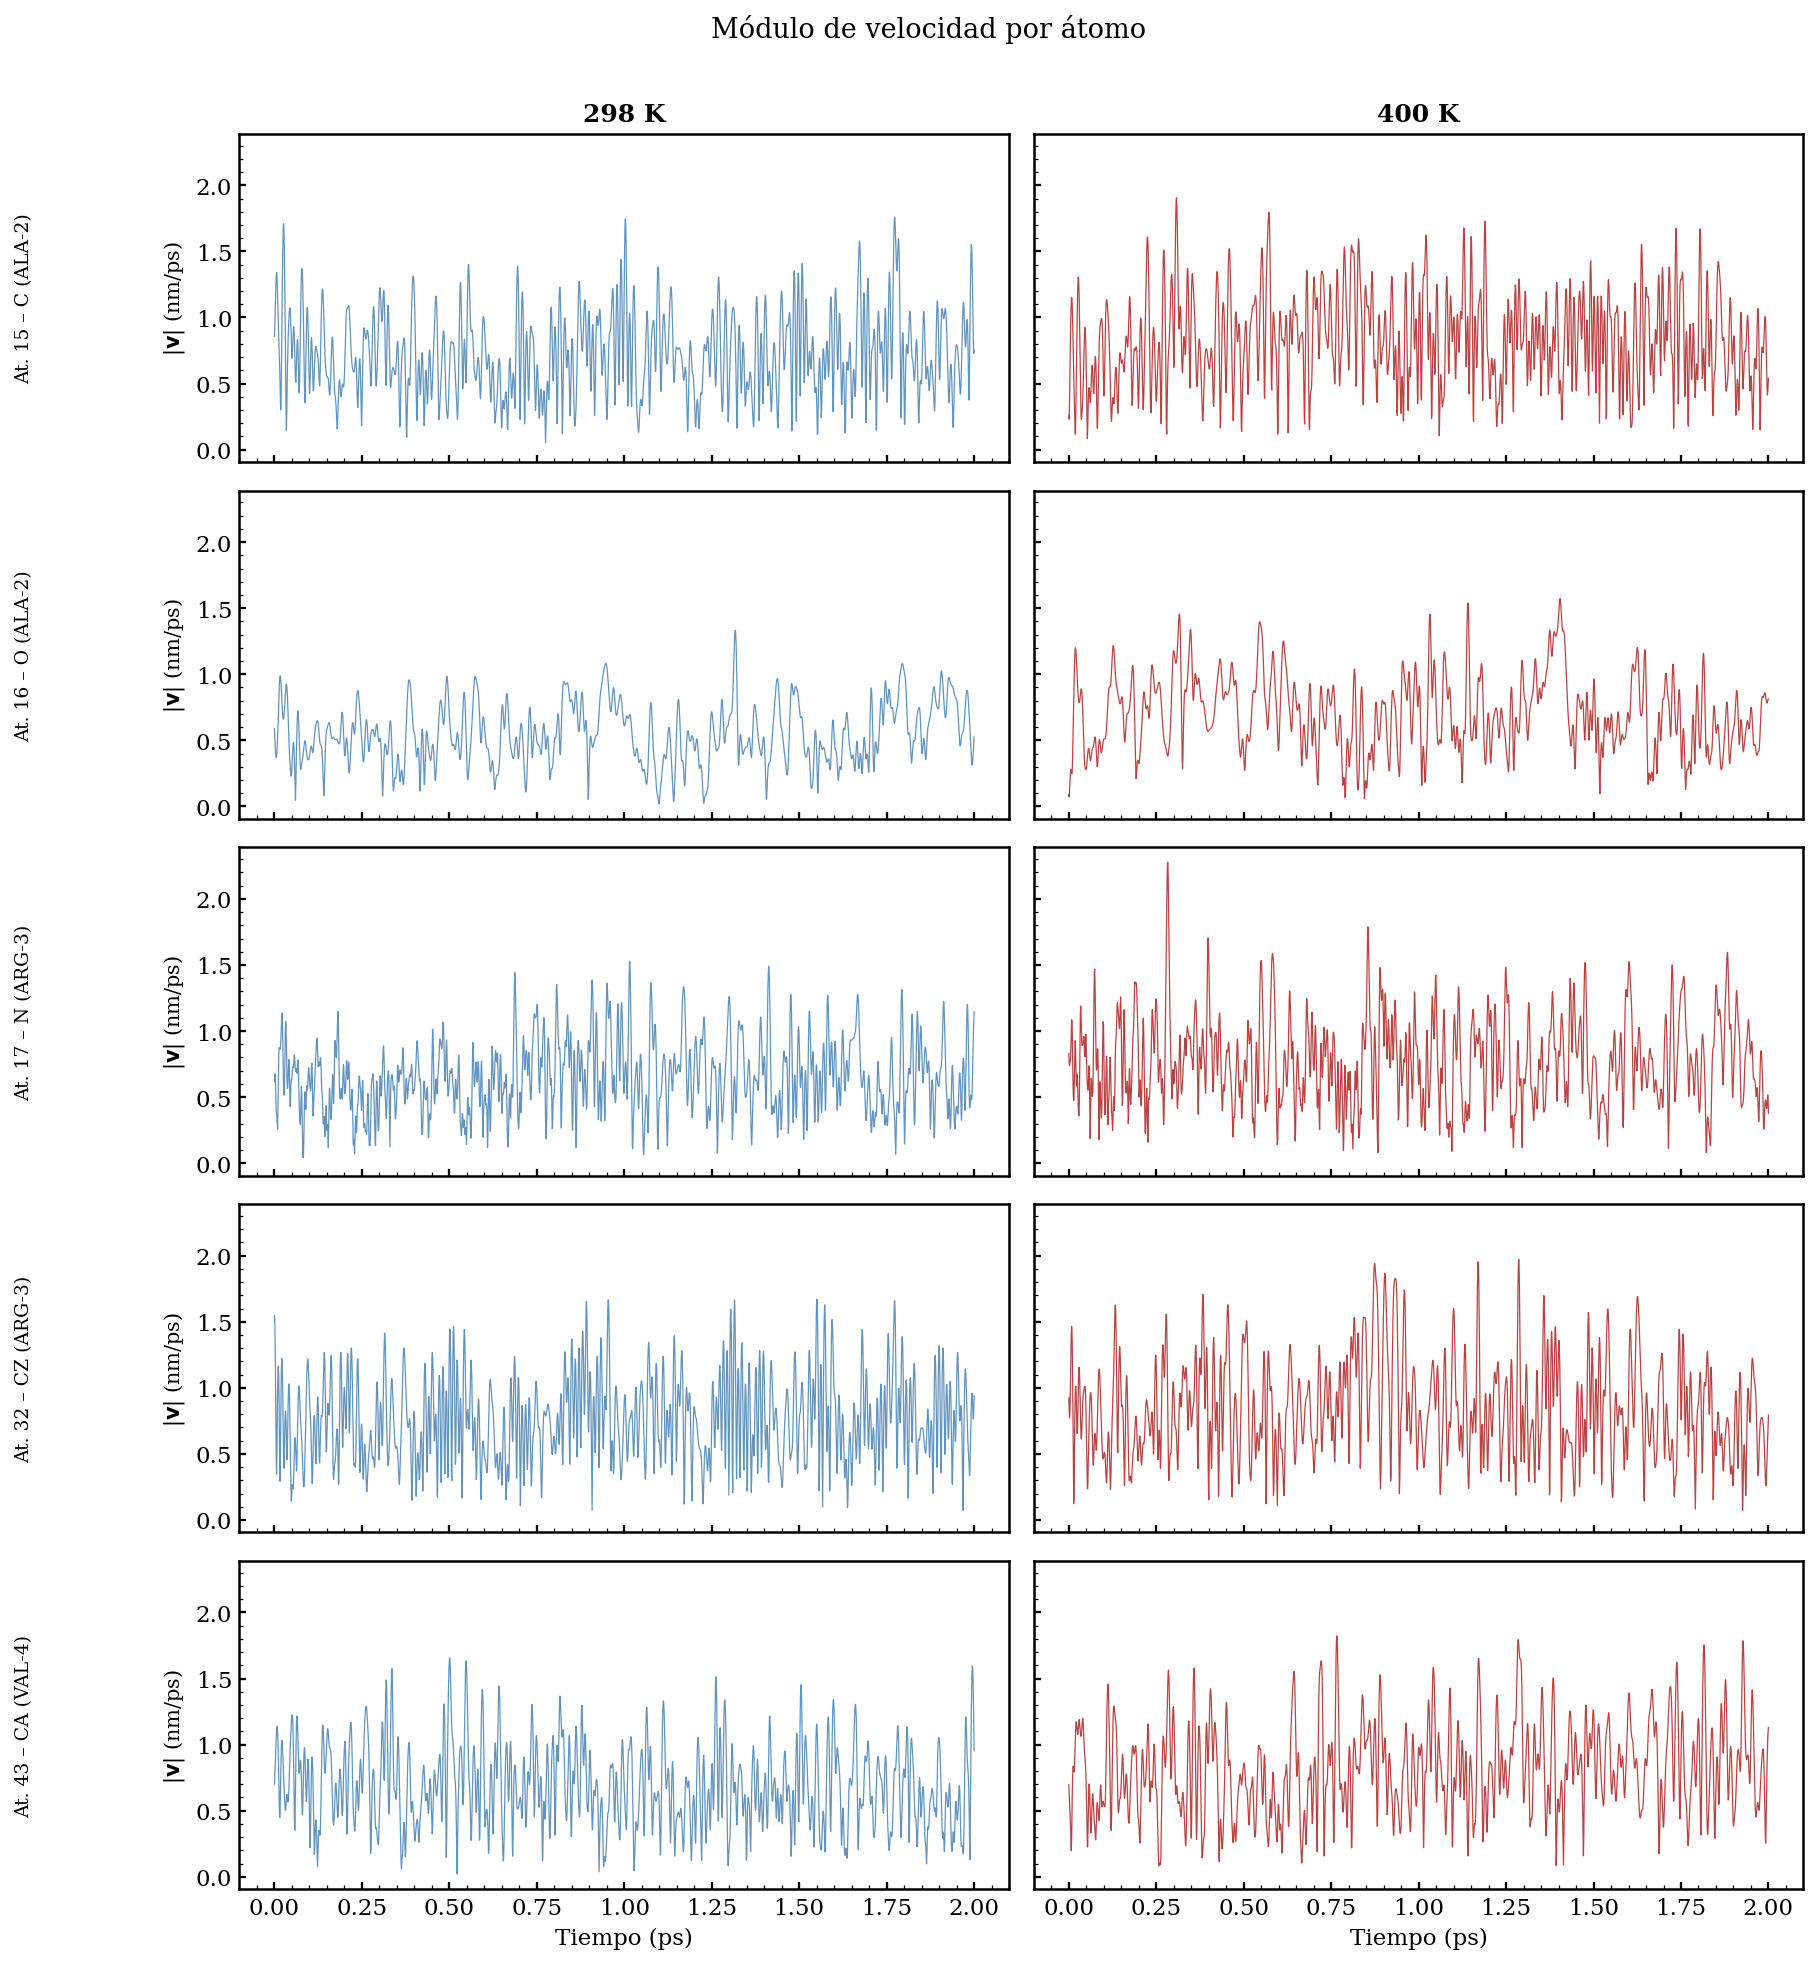

Figura guardada como veloc_speed_per_atom.png


In [11]:
fig, axes = plt.subplots(5, 2, figsize=(12, 13), sharex=True, sharey=True)

for row_i in range(5):
    atom = ATOMS[row_i]
    for col_j, (vel_dict, t_arr, T_nom, t_col) in enumerate([
            (vel_298, time_298, '298 K', 'steelblue'),
            (vel_400, time_400, '400 K', 'firebrick')]):

        ax = axes[row_i, col_j]
        ax.plot(t_arr, vel_dict[row_i]['speed'], color=t_col, lw=0.6, alpha=0.85)

        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

        if row_i == 0:
            ax.set_title(T_nom, fontsize=12, fontweight='bold')

        if col_j == 0:
            ax.set_ylabel(r'$|\mathbf{v}|$ (nm/ps)', fontsize=10)
            ax.annotate(f'At. {atom["id"]} – {atom["type"]} ({atom["res"]})',
                        xy=(-0.28, 0.5), xycoords='axes fraction',
                        fontsize=9, ha='center', va='center', rotation=90)

        if row_i == 4:
            ax.set_xlabel('Tiempo (ps)', fontsize=11)

fig.suptitle('Módulo de velocidad por átomo', fontsize=13, y=1.005)
fig.align_ylabels(axes[:, 0])

plt.tight_layout()
plt.savefig('veloc_speed_per_atom.png')
plt.show()
print('Figura guardada como veloc_speed_per_atom.png')

## 5. Evolución temporal por átomo — Comparativa superpuesta

Un panel por átomo con ambas temperaturas superpuestas (298 K y 400 K).

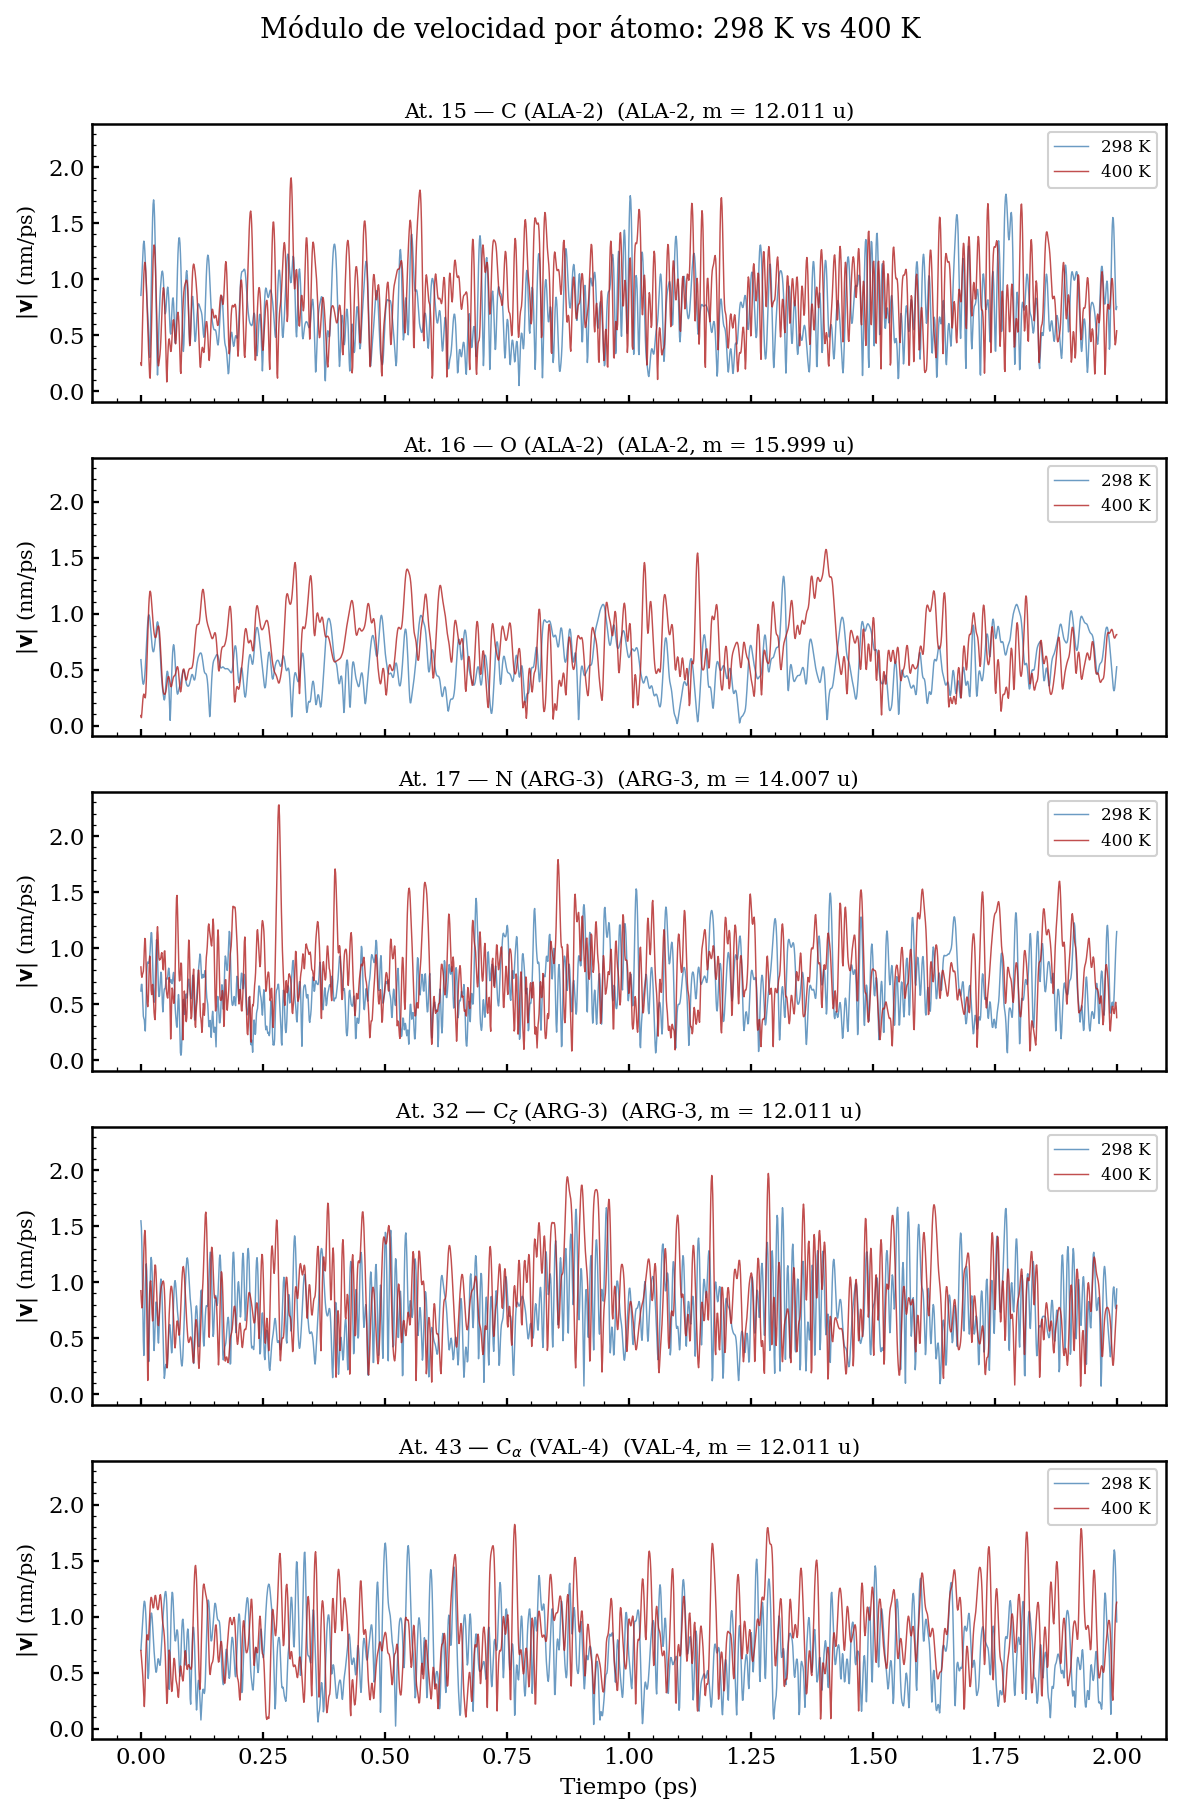

Figura guardada como veloc_speed_per_atom_overlay.png


In [12]:
fig, axes = plt.subplots(5, 1, figsize=(8, 12), sharex=True, sharey=True)

for ax, i in zip(axes, range(5)):
    atom = ATOMS[i]
    ax.plot(time_298, vel_298[i]['speed'], color='steelblue', lw=0.7, alpha=0.8,
            label='298 K')
    ax.plot(time_400, vel_400[i]['speed'], color='firebrick', lw=0.7, alpha=0.8,
            label='400 K')
    ax.set_ylabel(r'$|\mathbf{v}|$ (nm/ps)', fontsize=10)
    ax.set_title(f'At. {atom["id"]} — {atom["label"]}  ({atom["res"]}, m = {atom["mass"]} u)',
                 fontsize=10, pad=3)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Tiempo (ps)', fontsize=11)
fig.suptitle('Módulo de velocidad por átomo: 298 K vs 400 K', fontsize=13, y=1.005)
fig.align_ylabels()

plt.tight_layout()
plt.savefig('veloc_speed_per_atom_overlay.png')
plt.show()
print('Figura guardada como veloc_speed_per_atom_overlay.png')

## 6. Distribución de velocidades — Maxwell-Boltzmann

Histograma de $v_x$ de cada átomo (filas) a 298 K (columna izquierda, azul) y 400 K (columna derecha, rojo), con la curva gaussiana teórica de Maxwell-Boltzmann:

$f(v_x) = \sqrt{\frac{m}{2\pi k_B T}}\,\exp\!\left(-\frac{m\,v_x^2}{2\,k_B T}\right), \quad \sigma_{\text{MB}} = \sqrt{\frac{k_B T}{m}}$

para O (15.999 u) se espera la distribución más estrecha; para C/CZ (12.011 u) la más ancha.

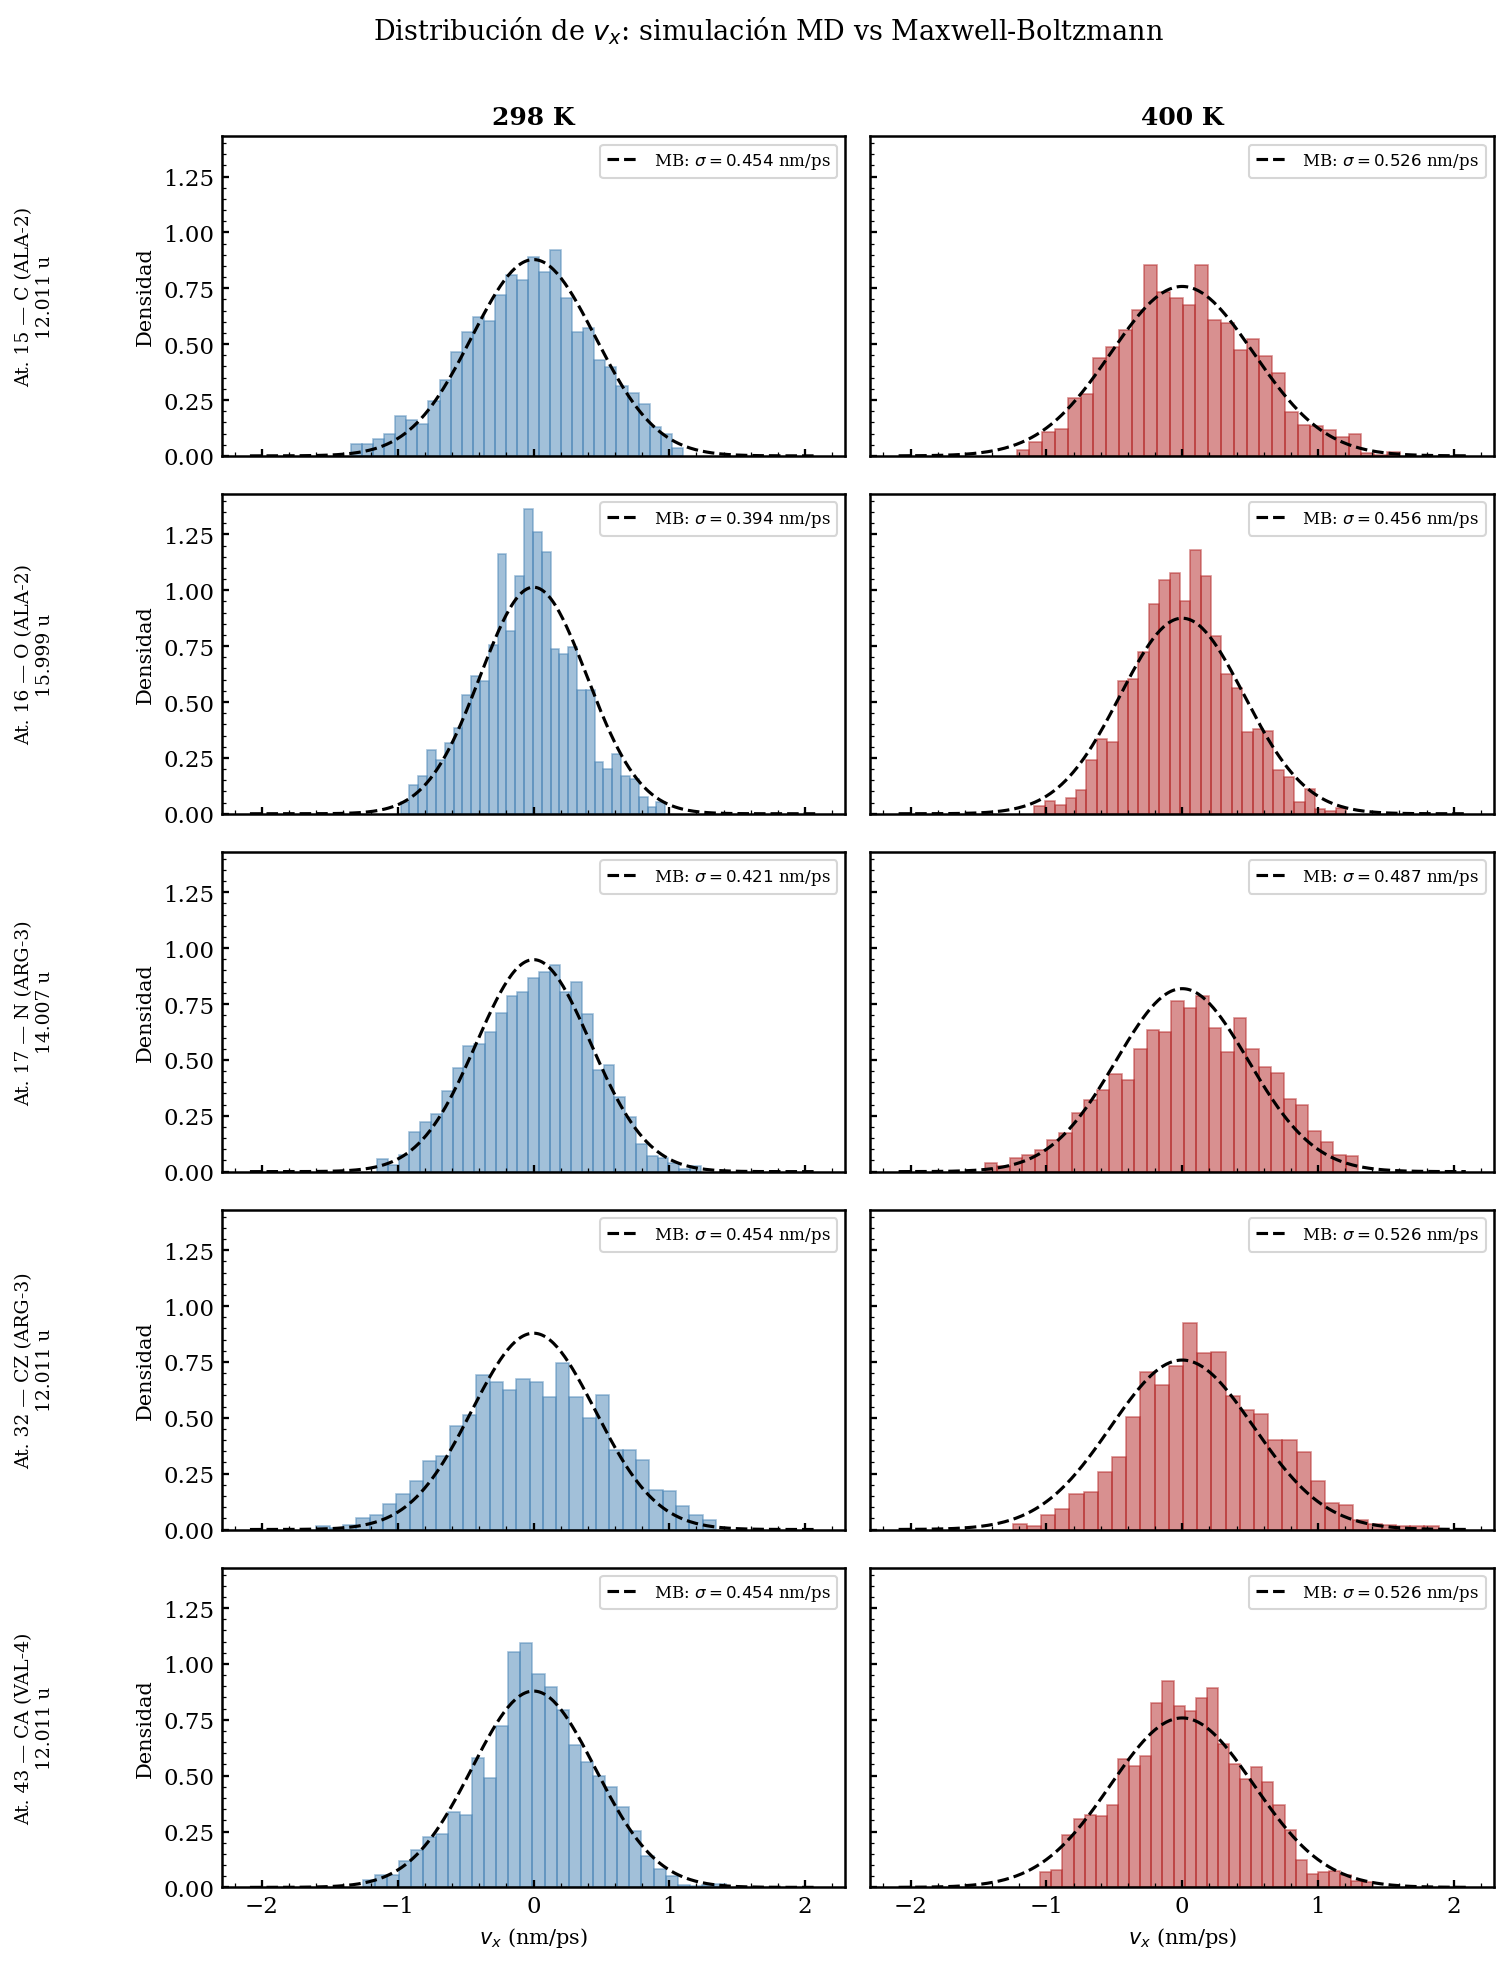

Figura guardada como veloc_vx_histograms_MB.png


In [13]:
kB = 1.380649e-23    # J/K
u_to_kg = 1.66054e-27  # kg/u
nmps_to_ms = 1e3       # 1 nm/ps = 1000 m/s

# Rango global en x — compartido entre todos los paneles
all_vx = np.concatenate([vel_298[i]['vx'] for i in range(5)] +
                        [vel_400[i]['vx'] for i in range(5)])
x_lim = np.max(np.abs(all_vx)) + 0.2
x_fit_global = np.linspace(-x_lim, x_lim, 300)

# Layout 5×2: filas = átomos, columnas = temperaturas
# sharex=True y sharey=True para comparar escala entre átomos y temperaturas
fig, axes = plt.subplots(5, 2, figsize=(10, 13), sharex=True, sharey=True)

temps = [(vel_298, 298, 'steelblue'), (vel_400, 400, 'firebrick')]

for row_i, atom in enumerate(ATOMS):
    m_kg = atom['mass'] * u_to_kg

    for col_j, (vel_dict, T_nom, t_col) in enumerate(temps):
        ax = axes[row_i, col_j]
        vx = vel_dict[row_i]['vx']

        ax.hist(vx, bins=30, density=True,
                color=t_col, alpha=0.5, edgecolor=t_col, linewidth=0.8)

        sigma_MB = np.sqrt(kB * T_nom / m_kg) / nmps_to_ms  # nm/ps
        ax.plot(x_fit_global, norm.pdf(x_fit_global, 0, sigma_MB),
                color='black', lw=1.5, ls='--',
                label=rf'MB: $\sigma={sigma_MB:.3f}$ nm/ps')

        ax.legend(loc='upper right', fontsize=8, framealpha=0.8)
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

        # Título de columna solo en fila superior
        if row_i == 0:
            ax.set_title(f'{T_nom} K', fontsize=12, fontweight='bold')

        # Etiqueta y solo en columna izquierda
        if col_j == 0:
            ax.set_ylabel('Densidad', fontsize=10)
            ax.annotate(f'At. {atom["id"]} — {atom["type"]} ({atom["res"]})\n{atom["mass"]} u',
                        xy=(-0.30, 0.5), xycoords='axes fraction',
                        fontsize=9, ha='center', va='center', rotation=90)

        # Etiqueta x solo en fila inferior
        if row_i == 4:
            ax.set_xlabel(r'$v_x$ (nm/ps)', fontsize=10)

fig.suptitle(r'Distribución de $v_x$: simulación MD vs Maxwell-Boltzmann',
             fontsize=13, y=1.005)
fig.align_ylabels(axes[:, 0])

plt.tight_layout()
plt.savefig('veloc_vx_histograms_MB.png')
plt.show()
print('Figura guardada como veloc_vx_histograms_MB.png')

## 7. Distribución de las tres componentes — Átomo seleccionado

Se muestran los histogramas de $v_x$, $v_y$ y $v_z$ para el **átomo 16 (O de ALA-2, 15.999 u)**,
el más pesado de la selección. Al ser el más pesado, su distribución es la más estrecha y la curva
de Maxwell-Boltzmann ajusta con mayor limpieza. Además corresponde al oxígeno del enlace C=O
analizado en la sección de distancias, aportando coherencia al informe.
Se superponen las dos temperaturas para visualizar el ensanchamiento isotrópico al calentar.

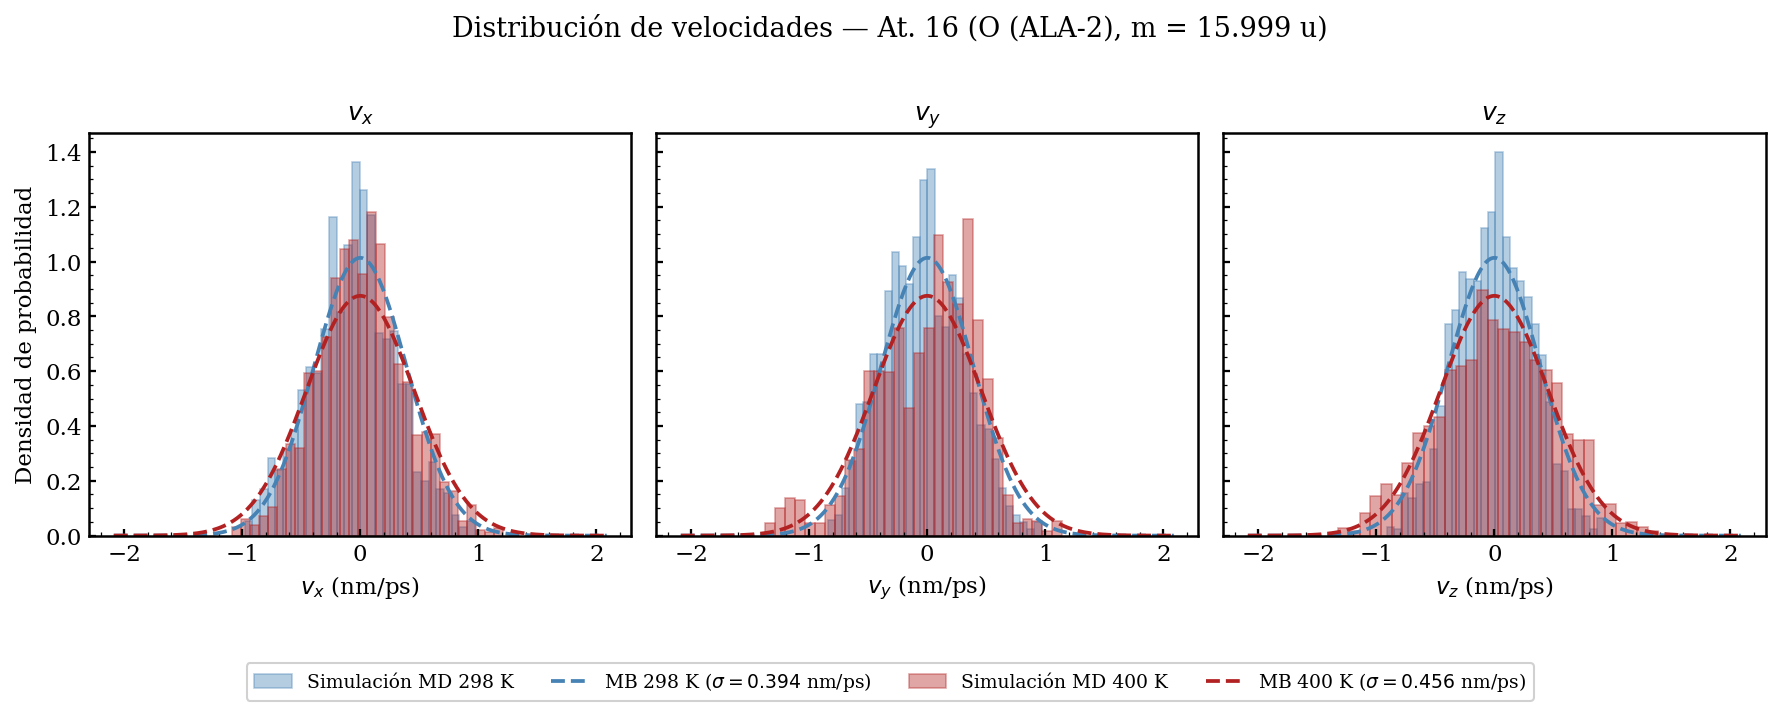

Figura guardada como veloc_3comp_at16.png


In [14]:
atom_sel  = 1          # índice → At. 16, O (ALA-2), 15.999 u
atom_info = ATOMS[atom_sel]
comp_labels = ['vx', 'vy', 'vz']
comp_math   = [r'$v_x$', r'$v_y$', r'$v_z$']

m_kg = atom_info['mass'] * u_to_kg

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, sharex=True)

for ax, comp, comp_m in zip(axes, comp_labels, comp_math):
    for vel_dict, T_nom, t_col in [(vel_298, 298, 'steelblue'),
                                    (vel_400, 400, 'firebrick')]:
        v = vel_dict[atom_sel][comp]
        sigma_MB = np.sqrt(kB * T_nom / m_kg) / nmps_to_ms  # nm/ps

        ax.hist(v, bins=30, density=True,
                color=t_col, alpha=0.4, edgecolor=t_col, linewidth=0.8,
                label=f'Simulación MD {T_nom} K')

        x_fit = np.linspace(-x_lim, x_lim, 300)
        ax.plot(x_fit, norm.pdf(x_fit, 0, sigma_MB),
                color=t_col, lw=1.8, ls='--',
                label=rf'MB {T_nom} K ($\sigma={sigma_MB:.3f}$ nm/ps)')

    ax.set_xlabel(f'{comp_m} (nm/ps)', fontsize=11)
    ax.set_title(comp_m, fontsize=12)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

axes[0].set_ylabel('Densidad de probabilidad', fontsize=11)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.14),
           ncol=4, fontsize=9)

fig.suptitle(
    f'Distribución de velocidades — At. {atom_info["id"]} '
    f'({atom_info["type"]} ({atom_info["res"]}), m = {atom_info["mass"]} u)',
    fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig(f'veloc_3comp_at{atom_info["id"]}.png')
plt.show()
print(f'Figura guardada como veloc_3comp_at{atom_info["id"]}.png')

## 8. Comparativa de ⟨|v|⟩ por átomo — Barras

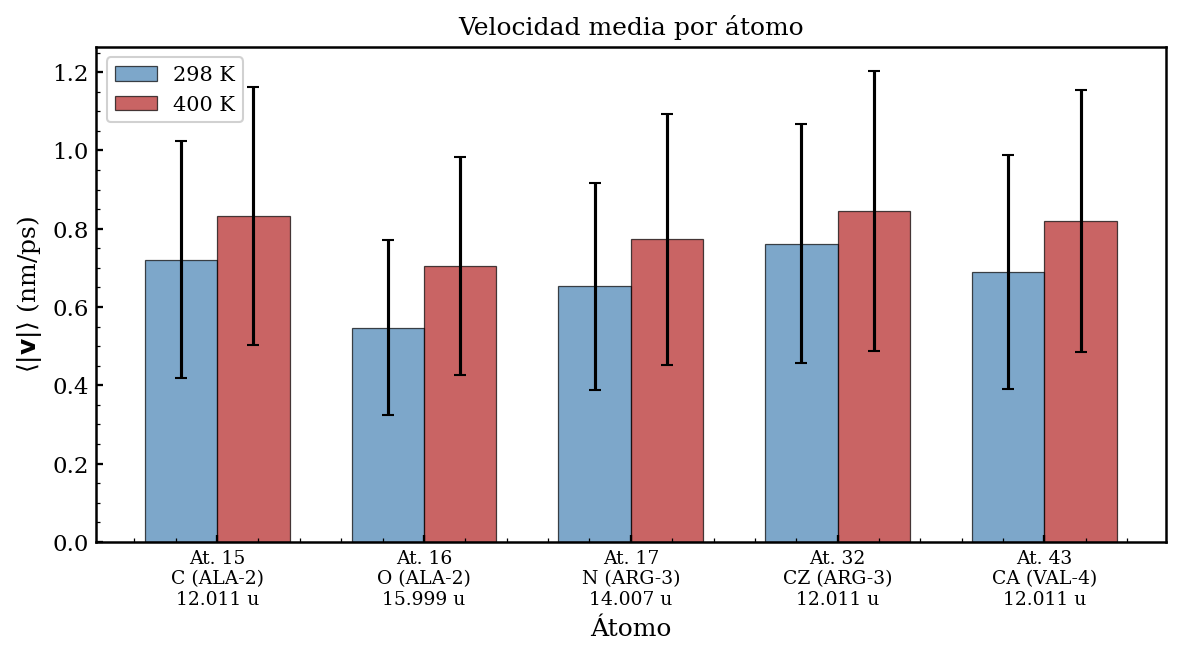

Figura guardada como veloc_mean_speed_bars.png


In [15]:
x = np.arange(len(ATOMS))
width = 0.35

means_298 = [vel_298[i]['speed'].mean() for i in range(5)]
means_400 = [vel_400[i]['speed'].mean() for i in range(5)]
stds_298  = [vel_298[i]['speed'].std()  for i in range(5)]
stds_400  = [vel_400[i]['speed'].std()  for i in range(5)]

fig, ax = plt.subplots(figsize=(8, 4.5))

bars1 = ax.bar(x - width/2, means_298, width, yerr=stds_298, capsize=3,
               color='steelblue', alpha=0.7, edgecolor='black', linewidth=0.6,
               label='298 K')
bars2 = ax.bar(x + width/2, means_400, width, yerr=stds_400, capsize=3,
               color='firebrick', alpha=0.7, edgecolor='black', linewidth=0.6,
               label='400 K')

ax.set_xlabel('Átomo')
ax.set_ylabel(r'$\langle |\mathbf{v}| \rangle$ (nm/ps)')
ax.set_title('Velocidad media por átomo')
ax.set_xticks(x)
ax.set_xticklabels(
    [f'At. {a["id"]}\n{a["type"]} ({a["res"]})\n{a["mass"]} u' for a in ATOMS],
    fontsize=9)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('veloc_mean_speed_bars.png')
plt.show()
print('Figura guardada como veloc_mean_speed_bars.png')

## 9. Resumen estadístico completo

In [16]:
final_rows = []
for T, vel_dict in [(298, vel_298), (400, vel_400)]:
    for i, atom in enumerate(ATOMS):
        sp = vel_dict[i]['speed']
        vx = vel_dict[i]['vx']
        m_kg = atom['mass'] * u_to_kg
        sigma_MB_298 = np.sqrt(kB * 298 / m_kg) / nmps_to_ms
        sigma_MB_400 = np.sqrt(kB * 400 / m_kg) / nmps_to_ms
        sigma_MB = sigma_MB_298 if T == 298 else sigma_MB_400
        final_rows.append({
            'T (K)':             T,
            'Átomo':             atom['id'],
            'Tipo':              atom['type'],
            'Residuo':           atom['res'],
            'Masa (u)':          atom['mass'],
            '⟨|v|⟩ (nm/ps)':    round(sp.mean(),  4),
            'σ(|v|)':            round(sp.std(),   4),
            '⟨vx⟩ (nm/ps)':     round(vx.mean(),  5),
            'σ(vx) sim.':        round(vx.std(),   4),
            'σ(vx) MB':          round(sigma_MB,   4),
            'Max |v|':           round(sp.max(),   4),
        })

final_df = pd.DataFrame(final_rows)

(final_df.style
    .format({
        'Masa (u)':          '{:.3f}',
        '⟨|v|⟩ (nm/ps)':    '{:.4f}',
        'σ(|v|)':            '{:.4f}',
        '⟨vx⟩ (nm/ps)':     '{:.5f}',
        'σ(vx) sim.':        '{:.4f}',
        'σ(vx) MB':          '{:.4f}',
        'Max |v|':           '{:.4f}',
    })
    .set_caption('Tabla 1. Estadística descriptiva de las velocidades atómicas a 298 K y 400 K.')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '13px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('margin-bottom', '6px')]},
        {'selector': 'th',
         'props': [('background-color', '#2c3e50'), ('color', 'white'),
                   ('text-align', 'center'), ('padding', '6px 10px'),
                   ('font-size', '12px')]},
        {'selector': 'td',
         'props': [('text-align', 'center'), ('padding', '5px 10px'),
                   ('font-size', '11px')]},
        {'selector': 'tr:nth-child(even)',
         'props': [('background-color', '#f0f4f8')]},
        {'selector': 'tr:hover',
         'props': [('background-color', '#d6e4f0')]},
    ])
    .apply(lambda col: [
        'background-color: #eaf4fb' if v == 298 else 'background-color: #fdecea'
        for v in col
    ], subset=['T (K)'])
    .hide(axis='index')
)


T (K),Átomo,Tipo,Residuo,Masa (u),⟨|v|⟩ (nm/ps),σ(|v|),⟨vx⟩ (nm/ps),σ(vx) sim.,σ(vx) MB,Max |v|
298,15,C,ALA-2,12.011,0.7212,0.3028,-0.03433,0.4673,0.4542,1.7595
298,16,O,ALA-2,15.999,0.5470,0.2230,-0.05188,0.3607,0.3935,1.3331
298,17,N,ARG-3,14.007,0.6523,0.2641,-0.00633,0.4243,0.4206,1.5273
298,32,CZ,ARG-3,12.011,0.7619,0.3063,0.00121,0.5349,0.4542,1.6697
298,43,CA,VAL-4,12.011,0.6887,0.2996,0.00840,0.4326,0.4542,1.6566
400,15,C,ALA-2,12.011,0.8324,0.3307,0.02927,0.5001,0.5262,1.9053
400,16,O,ALA-2,15.999,0.7049,0.2793,0.01435,0.3766,0.4559,1.5729
400,17,N,ARG-3,14.007,0.7731,0.3211,0.05757,0.5321,0.4873,2.2776
400,32,CZ,ARG-3,12.011,0.8462,0.3579,0.16046,0.4979,0.5262,1.9718
400,43,CA,VAL-4,12.011,0.8195,0.3336,0.03885,0.4588,0.5262,1.8231
